In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, roc_auc_score, average_precision_score,
                              PrecisionRecallDisplay)

df = pd.read_csv('../data/processed/bank_cleaned.csv')
X = df.drop(columns=['y', 'pdays'])
y = (df['y'] == 'yes').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

logreg_model = joblib.load('../models/logreg_model.pkl')
ada_model = joblib.load('../models/adaboost_model.pkl')

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, roc_auc_score, average_precision_score,
                              PrecisionRecallDisplay)

df = pd.read_csv('../data/processed/bank_cleaned.csv')
X = df.drop(columns=['y', 'pdays'])
y = (df['y'] == 'yes').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

logreg_model = joblib.load('../models/logreg_model.pkl')
ada_model = joblib.load('../models/adaboost_model.pkl')

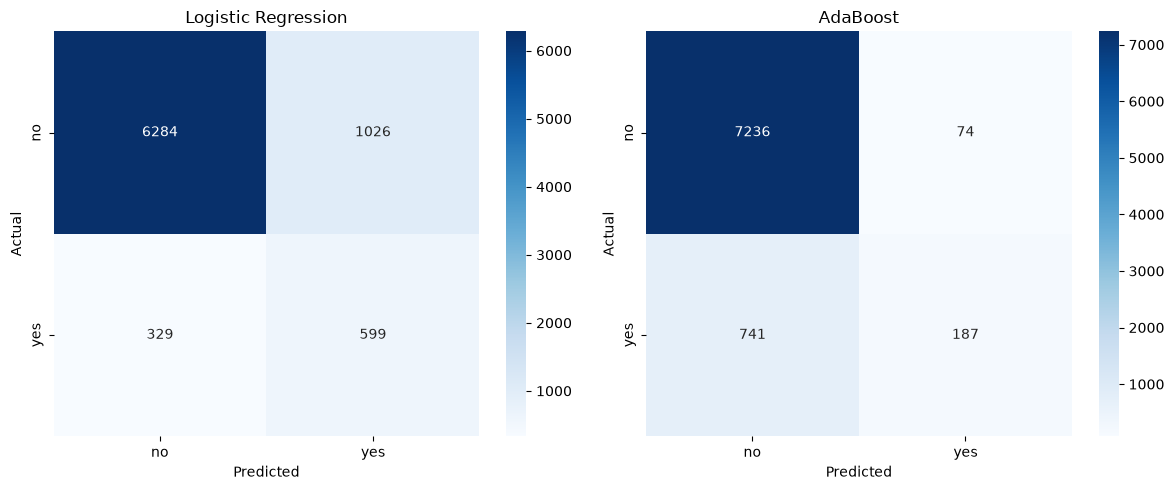

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, model) in zip(axes, [('Logistic Regression', logreg_model), ('AdaBoost', ada_model)]):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['no', 'yes'], yticklabels=['no', 'yes'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('../figures/02_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

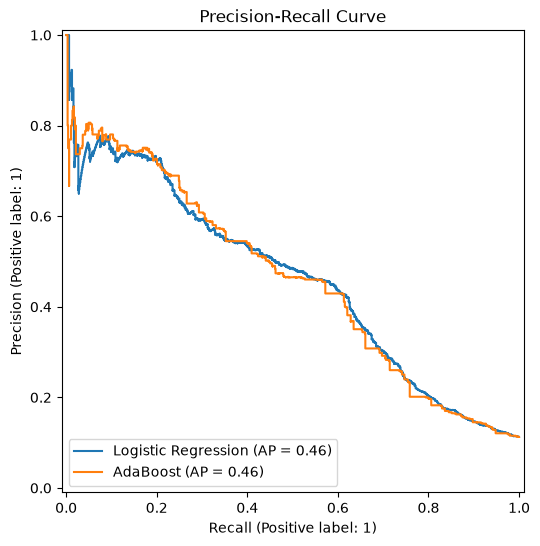

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in [('Logistic Regression', logreg_model), ('AdaBoost', ada_model)]:
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)
plt.title('Precision-Recall Curve')
plt.savefig('../figures/03_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\flowstxte\AppData\Local\Temp\ipykernel_9972\577144189.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include='object').columns.tolist()


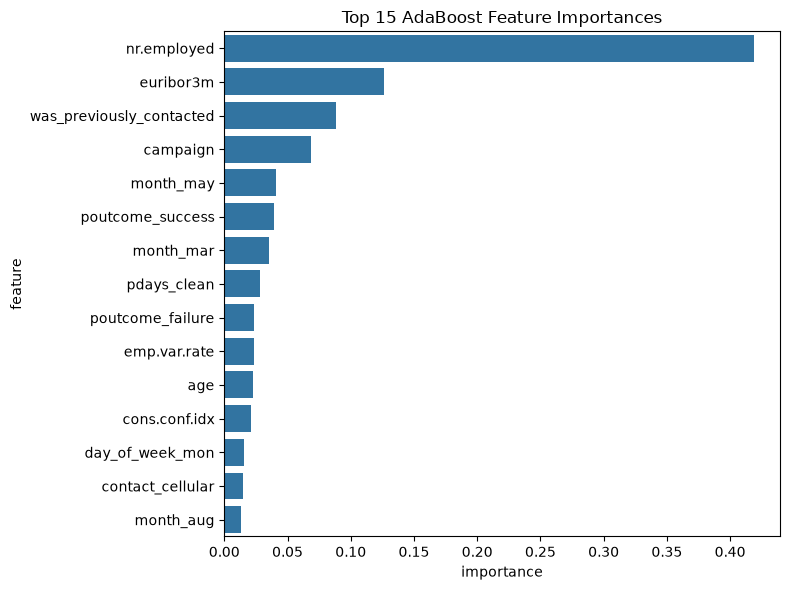

In [5]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

feature_names = (numeric_features +
    list(ada_model.named_steps['prep']
         .named_transformers_['cat'].get_feature_names_out(categorical_features)))

importances = ada_model.named_steps['clf'].feature_importances_
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=imp_df, x='importance', y='feature')
plt.title('Top 15 AdaBoost Feature Importances')
plt.tight_layout()
plt.savefig('../figures/04_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Concrete misclassification examples (used in report Section 7.3)
X_test_readable = X_test.copy()
X_test_readable['actual'] = y_test.values
X_test_readable['logreg_pred'] = logreg_model.predict(X_test)
X_test_readable['adaboost_pred'] = ada_model.predict(X_test)

fp_logreg = X_test_readable[(X_test_readable['actual']==0) & (X_test_readable['logreg_pred']==1)]
print("Logistic Regression false positives:")
print(fp_logreg.head(2))

fn_ada = X_test_readable[(X_test_readable['actual']==1) & (X_test_readable['adaboost_pred']==0)]
print("\nAdaBoost false negatives:")
print(fn_ada.head(2))

Logistic Regression false positives:
       age         job   marital            education  default housing loan  \
36380   37  unemployed   unknown    university.degree       no      no   no   
40076   73     retired  divorced  professional.course  unknown     yes   no   

        contact month day_of_week  ...  emp.var.rate  cons.price.idx  \
36380  cellular   jun         tue  ...          -2.9          92.963   
40076  cellular   jul         thu  ...          -1.7          94.215   

      cons.conf.idx  euribor3m  nr.employed  was_previously_contacted  \
36380         -40.8      1.262       5076.2                         0   
40076         -40.3      0.810       4991.6                         0   

       pdays_clean  actual  logreg_pred  adaboost_pred  
36380          0.0       0            1              0  
40076          0.0       0            1              0  

[2 rows x 23 columns]

AdaBoost false negatives:
       age          job  marital    education default housing loan 